<a href="https://colab.research.google.com/github/Anikk02/Tesla-Stock-Price-Forecasting/blob/main/Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Forecasting for E-Commerce

**OBJECTIVE**

The aim is to predict customer demand to optimize pricing and inventory management.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
data = pd.read_csv('train.csv')
#display the first few rows of the dataset
data.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [4]:
#check for missing values
data.isnull().sum()

,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,1
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [5]:
#Fill the missing values in 'total_price' with the  median of 'total_price' for the corresponding 'sku_id'

#median of the total_price for each sku_id
median_price_per_sku = data.groupby('sku_id')['total_price'].median()

#fill the missing value
data['total_price'].fillna(data['sku_id'].map(median_price_per_sku), inplace=True)

#check if there are any remaining missing values
data.isnull().sum()

/tmp/ipython-input-1043822607.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_price'].fillna(data['sku_id'].map(median_price_per_sku), inplace=True)


,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,0
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [6]:
#Convert the 'week' column to datetime format
from datetime import datetime
data['week'] = pd.to_datetime(data['week'])

#Aggregate the data by week
weekly_data = data.groupby('week')['units_sold'].sum().reset_index()

#display the first few rows of the aggregated data
weekly_data.head()


/tmp/ipython-input-4051950556.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['week'] = pd.to_datetime(data['week'])


,week,units_sold
0,2011-01-08,44134
1,2011-01-17,60029
2,2011-01-24,56752
3,2011-01-31,51467
4,2011-02-05,46077


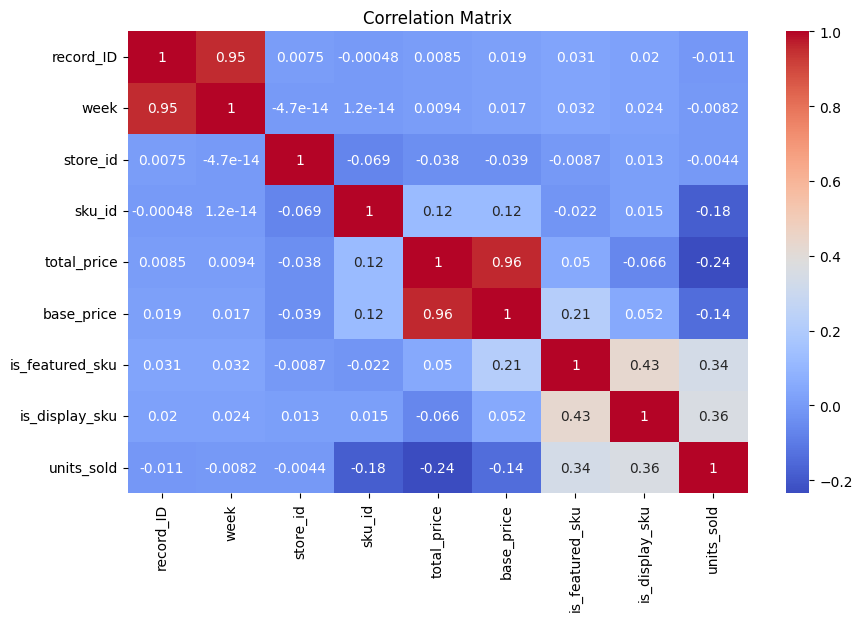

In [34]:
#Plot histograms for categorical columns and the target variable
'''categorical_cols = ['store_id','sku_id','is_featured_sku','is_display_sku','units_sold']

for col in categorical_cols:
    plt.figure(figsize=(10,6))
    plt.hist(data[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

#Boxplot for numerical columns
numerical_cols = ['total_price','base_price']
for col in numerical_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()'''

#check the correlation between features
correlation = data.corr()

#plot a heatmap of the correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


- Total price & base price (0.96):
Strong link because total price is largely determined by base price. Discounts/promotions play a minor role.
- Record_ID & week (0.95):
Sequential data entry causes this correlation. Record IDs increase in sync with weeks.
- Is_featured_sku & is_display_sku (0.43):
Featured items are often also displayed. This shows coordinated marketing strategies.
- Is_featured_sku & units_sold (0.34):
Featuring SKUs moderately boosts sales. Promotions make products more attractive to buyers.
- Is_display_sku & units_sold (0.36):
Displaying SKUs increases visibility. More visibility leads to higher sales.
- Sku_id & units_sold (-0.18):
Some SKUs underperform compared to others. SKU ID may reflect product category differences.
- Total price & units_sold (-0.24):
Higher prices reduce sales volume. Customers show price sensitivity.


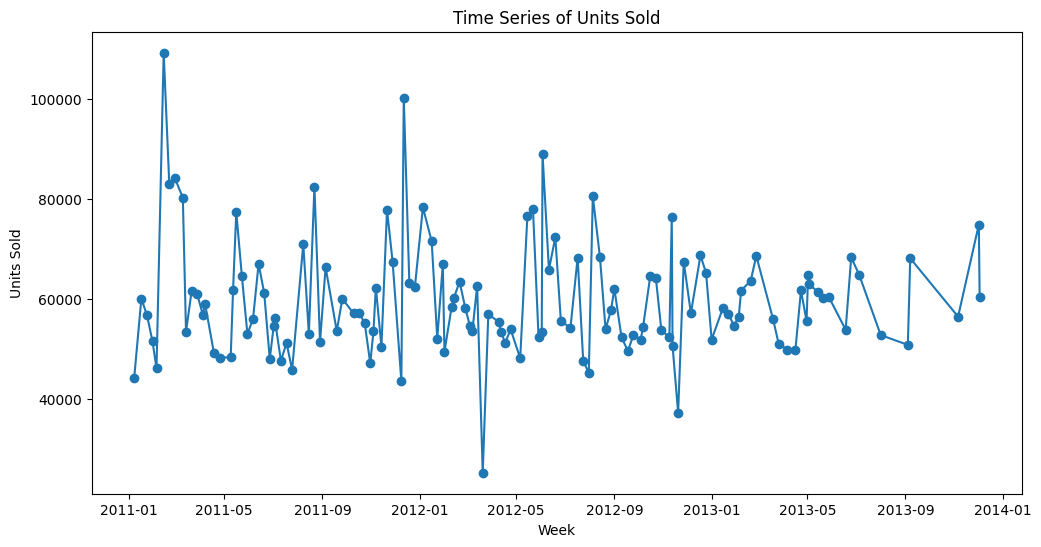

In [8]:
#Plot the time series of 'units_sold'
plt.figure(figsize=(12,6))
plt.plot(weekly_data['week'], weekly_data['units_sold'], marker='o', linestyle='-')
plt.title('Time Series of Units Sold')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.show()

Units sold fluctuated significantly between 2011 and 2014, showing clear seasonal peaks around early 2011 and 2012.
The overall trend is variable, with no consistent upward or downward movement across the entire period.
These patterns suggest cyclical demand, possibly influenced by promotions or seasonal buying behavior.


**Seasonality and Trend Analysis**

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

#set 'week' as the index for the data
weekly_data.set_index('week', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(weekly_data['units_sold'], model='additive', period=52 )

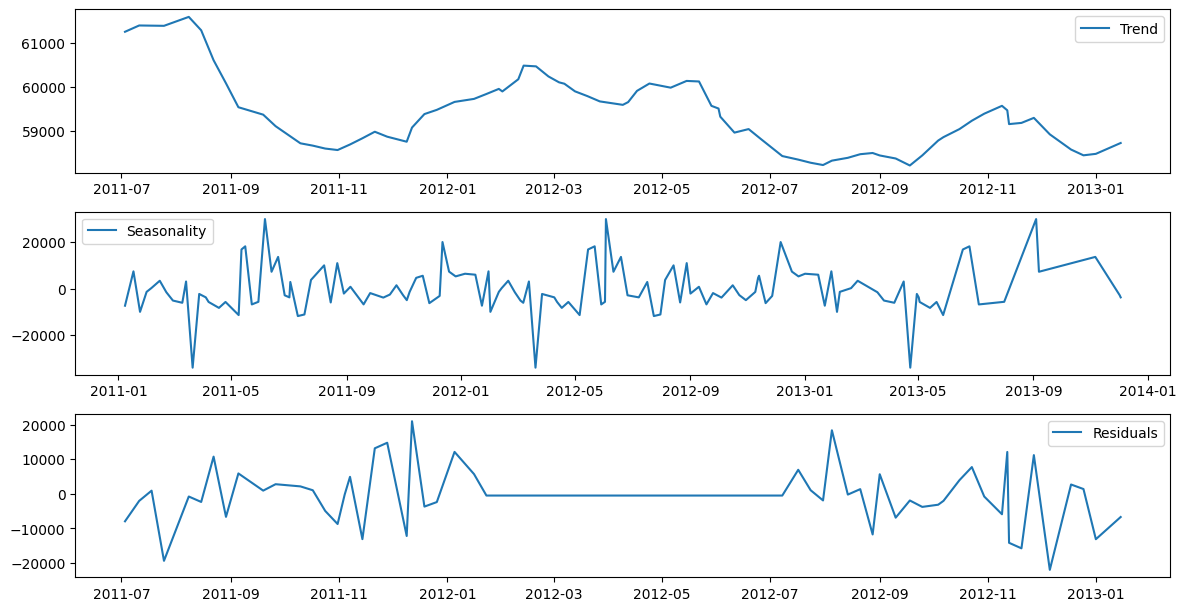

In [11]:
#Plot the trend, seasonality, and residuals
plt.figure(figsize=(12,8))

#Trend
plt.subplot(411)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')

#Seasonality
plt.subplot(412)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')

#Residuals
plt.subplot(413)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

1. Trend Component
  - The trend shows a gradual decline from mid-2011 to early 2013, with a peak around early 2012.
  - This suggests that overall sales were decreasing over time, possibly due to market saturation, reduced demand, or fewer promotions.

2. Seasonality Component
  - The seasonal pattern repeats consistently across years, fluctuating around zero.
  - This indicates cyclical behavior, such as higher sales during festive seasons or promotional periods, and lower sales during off-peak weeks.

3. Residuals Component
  - Residuals are mostly random noise, with no clear pattern  except for a flat section around early 2012.
  - This flat residual implies that during that period, the trend and seasonality explained most of the variation, leaving little unexplained randomness.




**Volatility Analysis**

Volatility refers to the variation of price of a financial instrument over time.

In [12]:
#Calculate the percentage change in the 'units_sold' from one week to the next
weekly_data['units_sold_pct_change']=weekly_data['units_sold'].pct_change()

#Calculate the standard deviation of these percentage change
volatility = weekly_data['units_sold_pct_change'].std()

print(f'Volatility of units sold: {volatility:.2%}')

Volatility of units sold: 30.39%


The standard deviation of the percentage change in units_sold from one week to next is approximately 30.40%. This means that there is a fair amount of volatility or fluctuation in weekly sales as the number of units sold can vary by about 30% from one week to the next.

**Moving Average**

Moving average is a commonly used technique in time series analysis to smooth out short-term fluctautions and highlights longer-term trends or cycles.

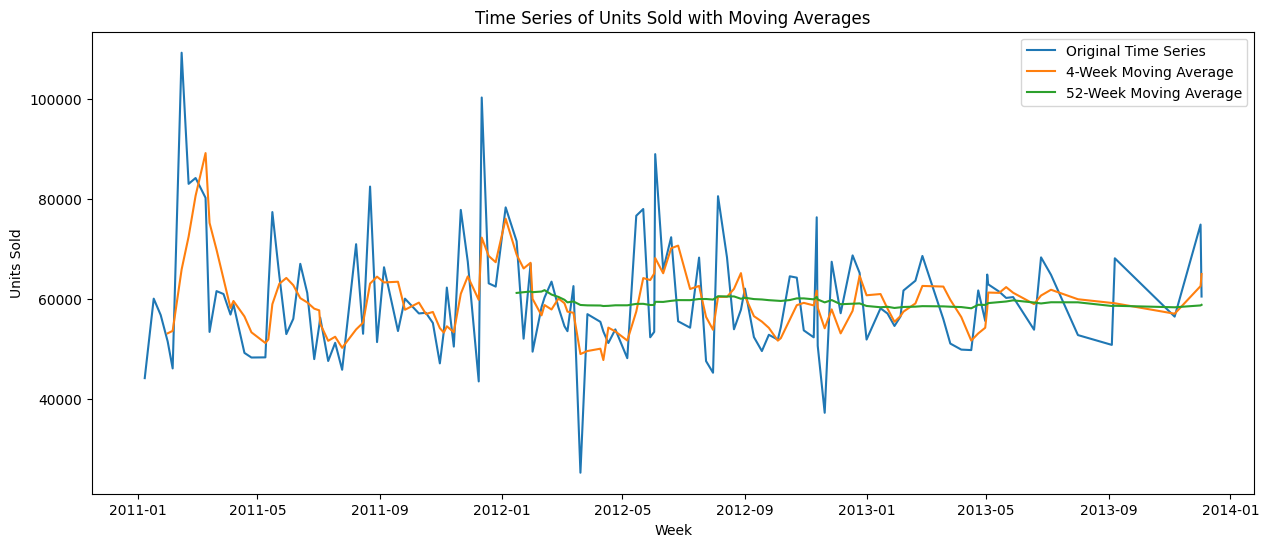

In [14]:
#Calculate the 4-week and 52-week moving averages
weekly_data['4_week_MA'] = weekly_data['units_sold'].rolling(window=4).mean()
weekly_data['52_week_MA'] = weekly_data['units_sold'].rolling(window=52).mean()

#Plot the original time series and the moving averages
plt.figure(figsize=(15,6))

plt.plot(weekly_data['units_sold'], label='Original Time Series')
plt.plot(weekly_data['4_week_MA'], label='4-Week Moving Average')
plt.plot(weekly_data['52_week_MA'], label='52-Week Moving Average')

plt.title('Time Series of Units Sold with Moving Averages')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

1. Original Time Series
  - Shows weekly fluctuations in units sold from 2011 to 2014. High variability suggest demand is influenced by short-term factors like promotions, holidays, or externals events.

2. 4-week Moving Average
  - Smooths out short-term noise and highlights monthly sales trends. Useful for identifying local peaks and dips, helping to detect short-term cycles or campaign effects.

3. 52-Week Moving Average
  - Captures long-term sales patterns and overall direction.
  Helps to reveal sustained growth or decline, filtering out seasonal and promotional spikes.

SUMMARY
- Exploratory Data Analysis:
   - The dataset contains sales data from multiple stores and for multiples SKUs. Most of the SKUs were neither featured nor displayed. There is a moderate positive correlation between is_featured_sku and is_display_sku and units_sold, including that when SKUs are featured or displayed, more units tend to be sold. There is slight negative correlation between total_price and units_sold, suggesting that lower priced items may sell in higher quantities.

- Time Series Analysis:
   - The time series of units_sold shows an irregular pattern with some apparent seasonality, but no clear increasing or decreasing trend. The decomposition of the time series revealed a stable trend component and a clear seasonal pattern that repeats annualy. The residuals show irregular fluctuations, which could be due to random variations or other factors not captured by the trend and seasonality. The volatility analysis showed that the number of units sold can vary by about 30.40% from one week to the next. The 4-week and 52-week moving average provided a smoothed view of the time seris.

Check the autocorrelation plot to confirm the presence of seasonality.

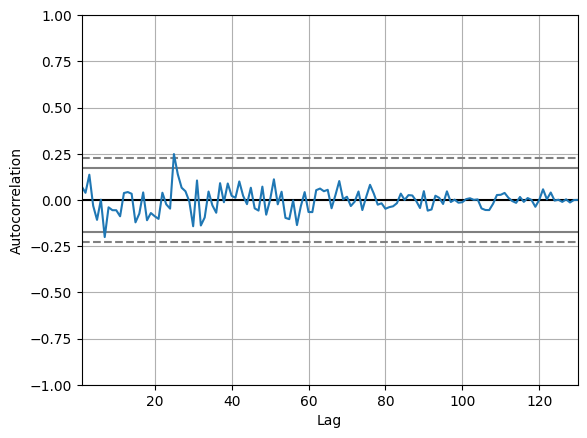

In [15]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(weekly_data['units_sold'])
plt.show()

The autocorrelation plot confirms the presence of seasonality in the data. We can see a sinusoidal pattern, which indicates a repeating pattern at regular intervals.

Fitting a Holt-Winters seasonal model to our data. Since the amplitude of the seasonal variation doesn't increase over time, we'll use the additive version of the Holt-Winters' method.

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from math import sqrt

#split the data into train and test sets
train_data = weekly_data['units_sold'][:int(len(weekly_data)*0.8)]
test_data = weekly_data['units_sold'][int(len(weekly_data)*0.8):]

#Fit the model
model = ExponentialSmoothing(train_data, seasonal_periods=52, seasonal='add').fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [20]:
#Resample the data to a weekly frequency
weekly_data_resampled = weekly_data['units_sold'].resample('W').mean().fillna(method='ffill')

#Split the resampled data into train and test sets
train_data_resampled = weekly_data_resampled[:int(0.8*(len(weekly_data_resampled)))]
test_data_resampled = weekly_data_resampled[int(0.8*(len(weekly_data_resampled))):]

#Fit the model to the resampled data
model_resampled = ExponentialSmoothing(train_data_resampled, seasonal_periods=52, seasonal='add', trend='add').fit()

#Generate predictions on the resampled data
predictions_resamppled = model_resampled.predict(start=test_data_resampled.index[0], end=test_data_resampled.index[-1])

#Calculate the root mean squared error on the resampled data
rmse_resampled = sqrt(mean_squared_error(test_data_resampled, predictions_resamppled))
print(f'RMSE on resampled data: {rmse_resampled}')

/tmp/ipython-input-3051409512.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weekly_data_resampled = weekly_data['units_sold'].resample('W').mean().fillna(method='ffill')


RMSE on resampled data: 11377.370430371058


The RMSE of ~11,377 units means the model’s weekly sales predictions deviate from actual values by about that amount on average.
Given sales range between 20,000 and 110,000 units, this error is moderate—smaller during high-volume weeks but larger during low-volume weeks.
It shows the model captures overall trends but struggles with sharp fluctuations and seasonal spikes.


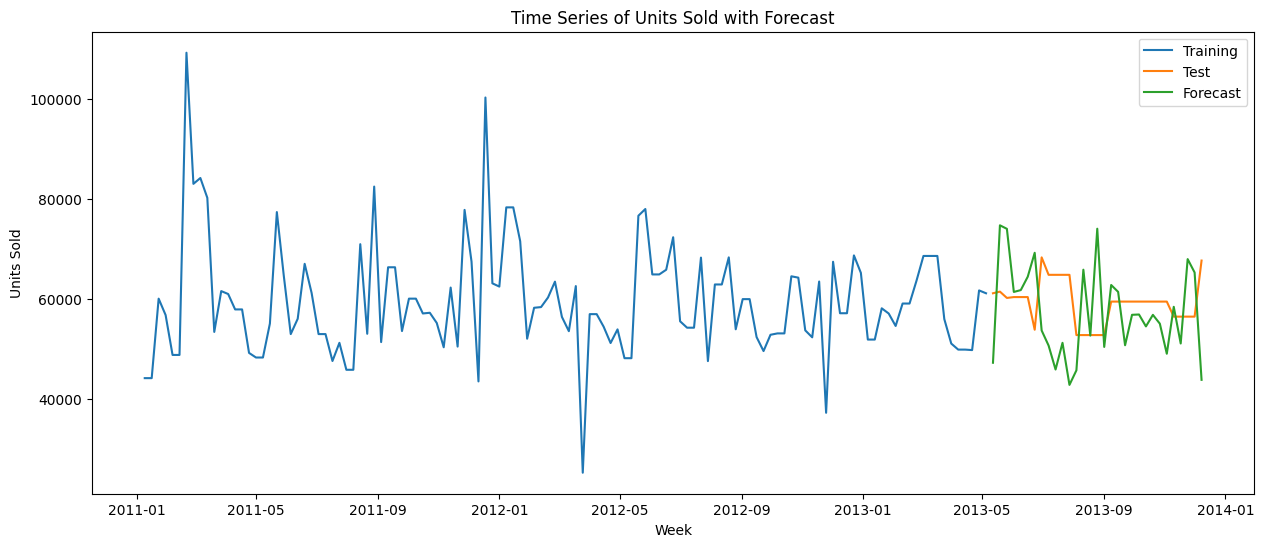

In [22]:
#Plot the original time series and the forecasted values
plt.figure(figsize=(15,6))

plt.plot(train_data_resampled, label='Training')
plt.plot(test_data_resampled, label='Test')
plt.plot(predictions_resamppled, label='Forecast')

plt.title('Time Series of Units Sold with Forecast')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

The model captures long-term patterns but underperforms during sudden demand changes or seasonal peaks.

In [24]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt

#Fit an ARIMA model
model_arima = ARIMA(train_data_resampled, order=(1,1,1))
model_arima_fit = model_arima.fit()

#Generate predictions from the ARIMA model
predictions_arima = model_arima_fit.predict(start=test_data_resampled.index[0], end=test_data_resampled.index[-1])

#Calculate error
rmse_arima = sqrt(mean_squared_error(test_data_resampled, predictions_arima))
print(f'RMSE on ARIMA model: {rmse_arima}')

RMSE on ARIMA model: 4491.93632911354


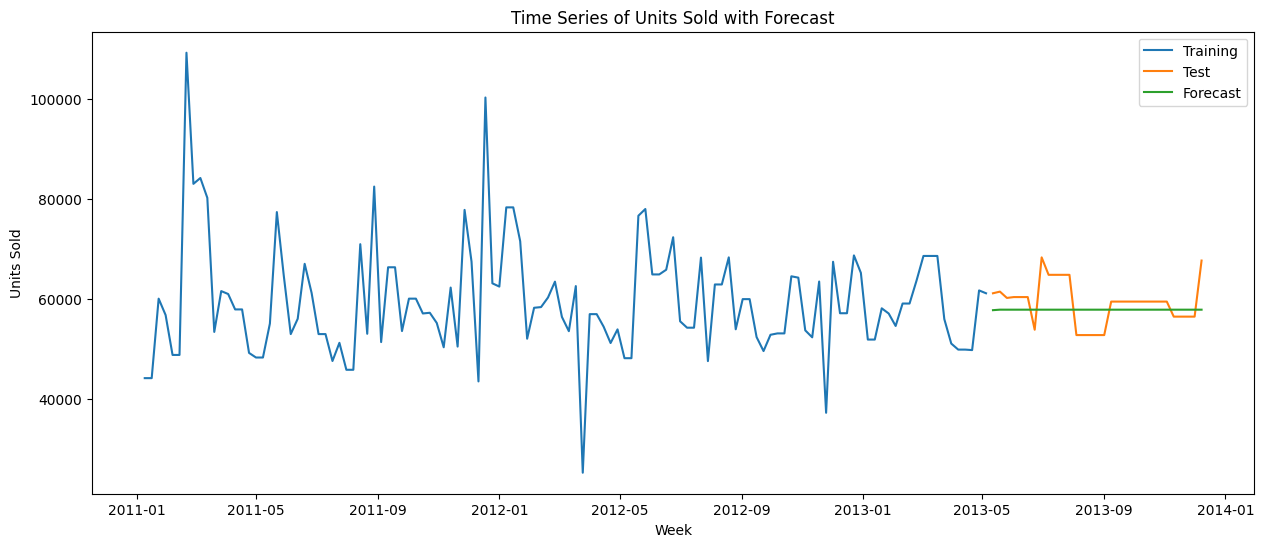

In [25]:
#Plot the original time series and the forecasted values
plt.figure(figsize=(15,6))

plt.plot(train_data_resampled, label='Training')
plt.plot(test_data_resampled, label='Test')
plt.plot(predictions_arima, label='Forecast')

plt.title('Time Series of Units Sold with Forecast')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

The ARIMA model achieved the lowest RMSE (~4,492 units), indicating strong statistical accuracy compared to other models.
However, its forecast appeared nearly as a straight line, failing to reflect the actual week-to-week fluctuations in sales.
This suggests ARIMA captured the overall level well but underfit the dynamic nature of the test data.
While numerically impressive, its lack of responsiveness limits its practical value for volatile retail forecasting.


In [29]:
#Prepare the data for the Prophet model
prophet_data = weekly_data.reset_index()
# Rename columns for Prophet
prophet_data.rename(columns={'week': 'ds', 'units_sold': 'y'}, inplace=True)

#Split the resampled data into train and test sets
train_data_prophet = prophet_data[:int(0.8*(len(prophet_data)))]
test_data_prophet = prophet_data[int(0.8*(len(prophet_data))):]
#Fit the Prophet model
model_prophet = Prophet(yearly_seasonality=True)
model_prophet.fit(train_data_prophet)

#Generate predictions from the Prophet model
future_dates = model_prophet.make_future_dataframe(periods=len(test_data_prophet))
predictions_prophet = model_prophet.predict(future_dates)

#Calculate the RMSE for the Prophet model
rmse_prophet = sqrt(mean_squared_error(test_data_prophet['y'], predictions_prophet['yhat'][-len(test_data_prophet):]))
print(f'RMSE on Prophet model: {rmse_prophet}')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


RMSE on Prophet model: 8882.305453724182


The Prophet model produced an RMSE of ~8,882 units, better than Exponential Smoothing but not as strong as ARIMA.
It captures overall trends and seasonal patterns well, but struggles slightly with short-term fluctuations.



SUMMARY
- Overall, while ARIMA was numerically the most accurate, its lack of responsiveness limits practical usefulness. Prophet offers a balanced trade-off between interpretability and accuracy, whereas Exponential Smoothing is least effective for this dataset.
